In [1]:
using Pkg
Pkg.activate("C:/Users/av589/Desktop/Julia/ants")
using BifurcationKit
using Plots
using DifferentialEquations
using LaTeXStrings
using JLD2
using CSV
using DataFrames

  Activating project at `C:\Users\av589\Desktop\Julia\ants`


In [2]:
function model_3d(x,p)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n)=p
    C,B,T = x
    S = 1 - C - B - T
    #Sdot = -(alphaC+alphaB+alphaT)*S + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n)
    Cdot = alphaC*S - omegaC*C/(1+ (C/k)^n)
    Bdot = alphaB*S - omegaB*B/(1 + (C/k)^n)
    Tdot = alphaT*S - beta*T
    [
        Sdot
        Cdot
        Tdot
    ]
end

function model_6d(x,p)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT)=p
    C,B,T,xC,xB,xT = x
    S = 1 - C - B - T
    #Sdot = -(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S + beta*T + (omegaC*C+omegaB*B)/(1 + (C/k)^n)
    Cdot = alphaC*(1+xC)*S - omegaC*C/(1 + (C/k)^n)
    Bdot = alphaB*(1+xB)*S - omegaB*B/(1 + (C/k)^n)
    Tdot = alphaT*(1+xT)*S - beta*T
    xCdot = -xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C))
    xBdot = -xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C))
    xTdot = -xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C))
    [
        Cdot
        Bdot
        Tdot
        xCdot
        xBdot
        xTdot
    ]
end

#function jac!(x, p)
#    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT)=p
##    J = [-alphaB*(x[5]+1)-alphaC*(x[4]+1)-alphaT*(x[6]+1)-omegaB/((x[2]/k)^n +1) -(n*(x[2]/k)^(n)*(omegaB*(-x[1]-x[2]-x[3]+1) + omegaC*x[2]))/(x[2]*((x[2]/k)^n +1)^2) + (-omegaB+omegaC)/((x[2]/k)^n + 1) beta - omegaB/((x[2]/k)^n +1) -alphaC*x[1] -alphaB*x[1] -alphaT*x[1];
  #  r2=alphaC*(x[2]+1) alphaC*x[1] + (n*omegaC*(x[2]/k)^n)/((x[2]/k)^n + 1)^2 - omegaC/((x[2]/k)^n +1) 0.0 0.0 0.0 0.0;
   ##r4=0.0 bC*u*(1- tanh(u*(aBC*x[5]+aC*x[4]+aTC*x[6]+bC*x[2]*x[4]))^2)*x[4] 0.0 u*(1-tanh(u*(aBC*x[5] + aC*x[4]+aTC*x[6]+bC*x[2]*x[4]))^2)*(aC + bC*x[2])-1 aBC*u*(1- tanh(u*(aBC*x[5]+aC*x[4]+aTC*x[6]+bC*x[2]*x[4]))^2) aTC*u*(1-tanh(u*(aBC*x[5]+aC*x[4]+aTC*x[6]+bC*x[2]*x[4]))^2);
   # r5=0.0 bB*u*(1-tanh(u*(aB*x[5]+aCB*x[4] + aTB*x[6] + bB*x[2]*x[5]))^2)*x[5] 0.0 aCB*u*(1-tanh(u*(aB*x[5]+aCB*x[4] + aTB*x[6] + bB*x[2]*x[5]))^2) u*(1- tanh(u*(aB*x[5]+aCB*x[4] + aTB*x[6] + bB*x[2]*x[5]))^2)*(aB+bB*x[2])-1 aTB*u*(1-tanh(u*(aB*x[5]+aCB*x[4] + aTB*x[6] + bB*x[2]*x[5]))^2);
   # r6=0.0 bT*u*(1-tanh(u*(aBT*x[5]+aCT*x[4]+aT*x[6]+bT*x[2]*x[6]))^2)*x[6] 0.0 aCT*u*(1-tanh(u*(aBT*x[5]+aCT*x[4]+aT*x[6]+bT*x[2]*x[6]))^2) aBT*u*(1- tanh(u*(aBT*x[5]+aCT*x[4]+aT*x[6]+bT*x[2]*x[6]))^2) u*(1- tanh(u*(aBT*x[5]+aCT*x[4]+aT*x[6]+bT*x[2]*x[6]))^2)*(aT + bT*x[2])-1]
   # return J
#end




model_6d (generic function with 1 method)

In [52]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,k=0.5,n=4,u=0.01,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3)
#par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.6,omegaB=0.5,k=0.5,n=4,u=0.1,aC=1.0,aB=1.0,aT=1.0,aBC=0.0,aTC=0.0,bC=-0.5,aCB=0.0,aTB=0.0,bB=-0.5,aCT=0.0,aBT=0.0,bT=0.5)

alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT = par
u0 = [0.0,0,0,0.0,0.0,0.0]
tspan=(0.0,30.0)

u_bif_problem = BifurcationProblem(model_6d, u0, par, (@optic _.u),record_from_solution = (x, p; k...) -> (C = x[1], B = x[2], T = x[3], xC = x[4], xB = x[5], xT = x[6]))

opts_br = ContinuationPar(
    p_min = 0.0, p_max = 1.5,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 3,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)


u_branch_equilibria = continuation(u_bif_problem, PALC(),opts_br)

 ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 270
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter u starts at 0.01, ends at 1.5
 ├─ Algo: PALC
 └─ Special points:

- #  1, endpoint at u ≈ +1.50000000,                                                                     step = 269


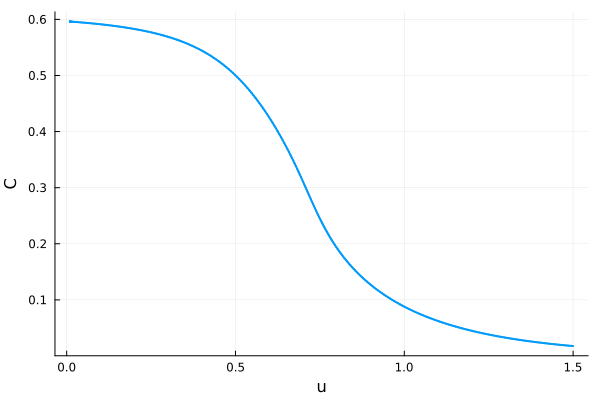

In [44]:
plot(u_branch_equilibria,vars=(:param, :C))

In [53]:
opts_br = ContinuationPar(
    p_min = 0.0, p_max = 2.5,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 3,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

# automatic bifurcation diagram computation
diagram = bifurcationdiagram(u_bif_problem,PALC(),
	4,
	opts_br,bothside = true
	)

[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Children number: 0
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 417
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter u starts at 0.0, ends at 2.427476047818639
      ├─ Algo: PALC
      └─ Special points:

- #  1, endpoint at u ≈ +0.00000000,                                                                     step =   0
- #  2, endpoint at u ≈ +2.43454703,                                                                     step = 417


In [59]:
#fieldnames(typeof(u_branch_equilibria)) # just for reference
pythonplot() # run once
scalefontsizes(1.5) # run once

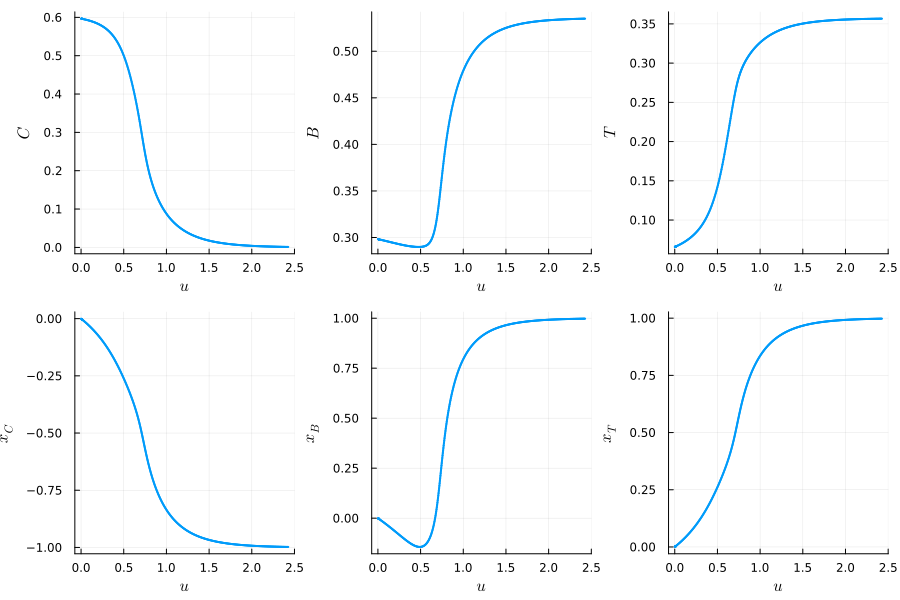

In [55]:
p1 = plot(diagram,vars = (:param,:C),ylabel = L"C",label ="",xlabel = L"u")#,ylims = (0.1,0.2),xlims = (0.5,0.7))
p2 = plot(diagram,vars = (:param,:B),ylabel = L"B",label = "",xlabel = L"u")
p3 = plot(diagram,vars = (:param,:T),ylabel = L"T",label = "",xlabel = L"u")
p4 = plot(diagram,vars = (:param,:xC),ylabel = L"x_C",label = "",xlabel = L"u")
p5 = plot(diagram,vars = (:param,:xB),ylabel = L"x_B",label = "",xlabel = L"u")
p6 = plot(diagram,vars = (:param,:xT),ylabel = L"x_T",label = "",xlabel = L"u")

FIG = plot(p1,p2,p3,p4,p5,p6, layout = 6,size = (900,600))#,dpi=300)
#png(FIG,"bif_diag")

In [56]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,k=0.5,n=4,u=1.6,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3)
#par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.6,omegaB=0.5,k=0.5,n=4,u=0.1,aC=1.0,aB=1.0,aT=1.0,aBC=0.0,aTC=0.0,bC=-0.5,aCB=0.0,aTB=0.0,bB=-0.5,aCT=0.0,aBT=0.0,bT=0.5)

alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT = par
u0 = [1.0,0,0,1.0,-1.0,-1.0]
tspan=(0.0,30.0)

u_bif_problem = BifurcationProblem(model_6d, u0, par, (@optic _.u),record_from_solution = (x, p; k...) -> (C = x[1], B = x[2], T = x[3], xC = x[4], xB = x[5], xT = x[6]))


opts_br = ContinuationPar(
    p_min = 0.61, p_max = 2.5,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 3,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

# automatic bifurcation diagram computation
diagram2 = bifurcationdiagram(u_bif_problem,PALC(),
	0,
	opts_br,bothside = true
	)

[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Children number: 0
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 301
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter u starts at 2.5, ends at 2.5
      ├─ Algo: PALC
      └─ Special points:

- #  1, endpoint at u ≈ +2.50000000,                                                                     step =   0
- #  2,       bp at u ≈ +1.72837369 ∈ (+1.72837203, +1.72837369), |δp|=2e-06, [converged], δ = (-1,  0), step = 111
- #  3,       bp at u ≈ +1.59063143 ∈ (+1.59063143, +1.59063143), |δp|=7e-12, [converged], δ = (-1,  0), step = 136
- #  4, endpoint at u ≈ +2.50000000,                                                                     step = 300


In [77]:
p1 = plot(diagram,vars = (:param,:C),ylabel = L"C",label ="",xlabel = L"u")#,ylims = (0.1,0.2),xlims = (0.5,0.7))
plot!(diagram2,vars = (:param,:C),ylabel = L"C",label ="",xlabel = L"u", plotspecialpoints = false)#,ylims = (0.1,0.2),xlims = (0.5,0.7)))
p2 = plot(diagram,vars = (:param,:B),ylabel = L"B",label = "",xlabel = L"u")
plot!(diagram2,vars = (:param,:B),ylabel = L"B",label = "",xlabel = L"u", plotspecialpoints = false)
p3 = plot(diagram,vars = (:param,:T),ylabel = L"T",label = "",xlabel = L"u")
plot!(diagram2,vars = (:param,:T),ylabel = L"T",label = "",xlabel = L"u", plotspecialpoints = false)
p4 = plot(diagram,vars = (:param,:xC),ylabel = L"x_C",label = "",xlabel = L"u")
plot!(diagram2,vars = (:param,:xC),ylabel = L"x_C",label = "",xlabel = L"u", plotspecialpoints = false)
p5 = plot(diagram,vars = (:param,:xB),ylabel = L"x_B",label = "",xlabel = L"u")
plot!(diagram2,vars = (:param,:xB),ylabel = L"x_B",label = "",xlabel = L"u", plotspecialpoints = false)
p6 = plot(diagram,vars = (:param,:xT),ylabel = L"x_T",label = "",xlabel = L"u")
plot!(diagram2,vars = (:param,:xT),ylabel = L"x_T",label = "",xlabel = L"u", plotspecialpoints = false)




#p1 = plot(diagram2,vars = (:param,:C),ylabel = L"C",label ="",xlabel = L"u")#,ylims = (0.1,0.2),xlims = (0.5,0.7))
#p2 = plot(diagram2,vars = (:param,:B),ylabel = L"B",label = "",xlabel = L"u")
#p3 = plot(diagram2,vars = (:param,:T),ylabel = L"T",label = "",xlabel = L"u")
#p4 = plot(diagram2,vars = (:param,:xC),ylabel = L"x_C",label = "",xlabel = L"u")
#p5 = plot(diagram2,vars = (:param,:xB),ylabel = L"x_B",label = "",xlabel = L"u")
#p6 = plot(diagram2,vars = (:param,:xT),ylabel = L"x_T",label = "",xlabel = L"u")

FIG = plot(p1,p2,p3,p4,p5,p6, layout = 6,size = (1100,600),dpi=300)
png(FIG,"bif_diag")

"bif_diag.png"